In [1]:
# pip install seaborn

In [2]:
import sys
import tensorflow as tf
import seaborn as sns
import numpy as np
print("Python:", sys.version)
print("Python executable:", sys.executable)
print("TensorFlow:", tf.__version__)

C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Python: 3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]
Python executable: C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\python.exe
TensorFlow: 2.21.0


In [3]:
import os

path = r"C:\Data Science"

print(os.listdir(path))

['NEU-DET', 'Testing', 'Training']


In [4]:
import os

training_path = r"C:\Data Science\Training"

print(os.listdir(training_path))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
import os

testing_path = r"C:\Data Science\Testing"

print(os.listdir(testing_path))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
#Checking the datset is balance or not

In [7]:
import os

training_path = r"C:\Data Science\Training"
testing_path = r"C:\Data Science\Testing"

classes = ["glioma", "meningioma", "notumor", "pituitary"]

print("TRAINING IMAGES")
print("----------------")

for class_name in classes:
    class_path = os.path.join(training_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}: {len(images)}")


print("\nTESTING IMAGES")
print("----------------")

for class_name in classes:
    class_path = os.path.join(testing_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}: {len(images)}")

TRAINING IMAGES
----------------
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

TESTING IMAGES
----------------
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


In [8]:
#Checking image dimension and format

In [9]:
from PIL import Image
import os

training_path = r"C:\Data Science\Training"

classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

for class_name in classes:

    class_path = os.path.join(
        training_path,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Take first image
    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    print(
        f"{class_name}: "
        f"Size={image.size}, "
        f"Mode={image.mode}, "
        f"Format={image.format}"
    )

glioma: Size=(512, 512), Mode=L, Format=JPEG
meningioma: Size=(512, 512), Mode=RGB, Format=JPEG
notumor: Size=(201, 251), Mode=RGB, Format=JPEG
pituitary: Size=(512, 512), Mode=RGB, Format=JPEG


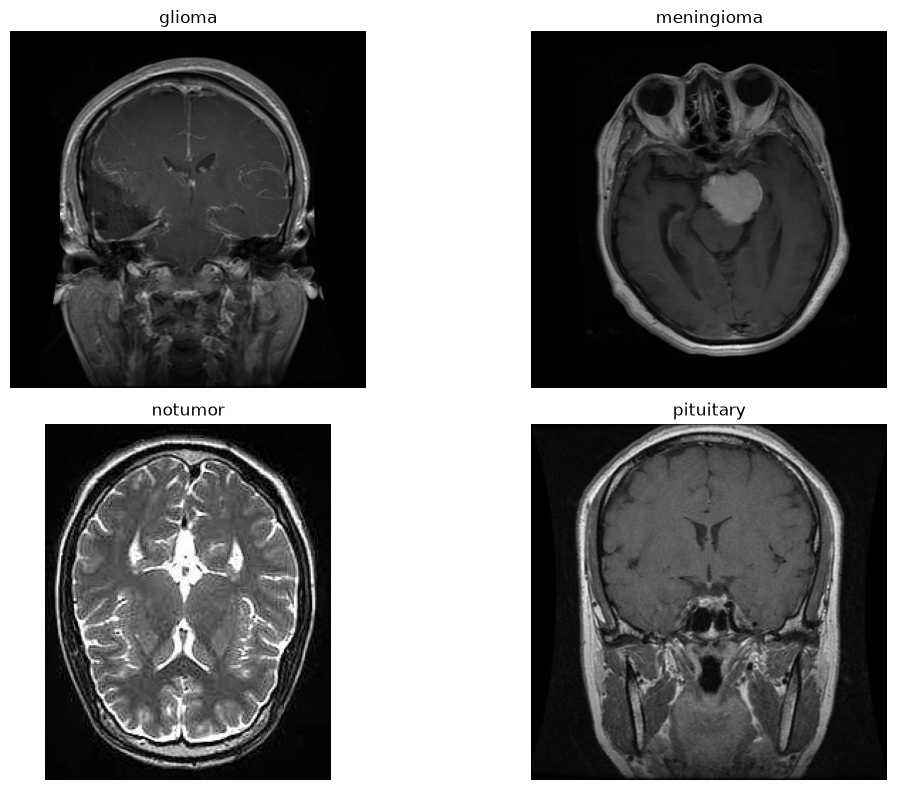

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt

training_path = r"C:\Data Science\Training"

classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(
        training_path,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
#Resize and normalizaton

In [12]:
import os

# Dataset paths
train_dir = r"C:\Data Science\Training"
test_dir = r"C:\Data Science\Testing"

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Classes
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Training path:", train_dir)
print("Testing path:", test_dir)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)

Training path: C:\Data Science\Training
Testing path: C:\Data Science\Testing
Image size: (224, 224)
Batch size: 32
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [13]:
#Loading the images and preproccessing them

In [14]:
import tensorflow as tf

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load testing dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDatasets loaded successfully!")
print("Class names:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.

Datasets loaded successfully!
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
#Check image tensor shape 

In [16]:
# Take one batch from the training dataset
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

print("Data type:", images.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)
Minimum pixel value: 0.0
Maximum pixel value: 255.0
Data type: <dtype: 'float32'>


In [17]:
#Normalization

In [18]:
id="2j2z1w"
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)

normalized_train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

normalized_test_dataset = test_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

# Check normalized values
normalized_images, normalized_labels = next(
    iter(normalized_train_dataset)
)

print(
    "Minimum pixel value:",
    tf.reduce_min(normalized_images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(normalized_images).numpy()
)

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [19]:
#Create the augmentation layers

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomFlip("horizontal")
], name="data_augmentation")

print("Data augmentation layer created successfully.")

Data augmentation layer created successfully.


In [21]:
#Visualize augmented MRI images

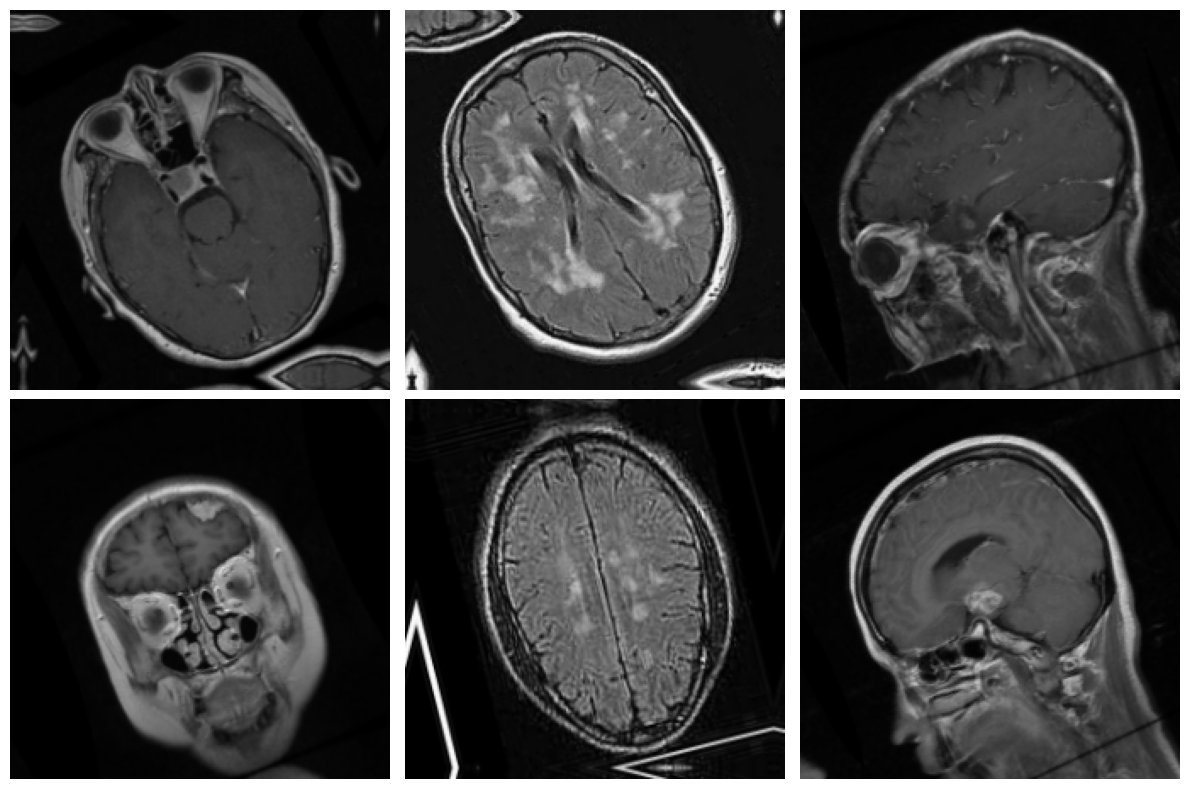

In [22]:
import matplotlib.pyplot as plt

# Get one batch from the normalized dataset
images, labels = next(iter(normalized_train_dataset))

plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = data_augmentation(
        images[i:i+1],
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image.numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
#Build a basline CNN

In [24]:
from tensorflow import keras
from tensorflow.keras import layers

baseline_cnn = keras.Sequential([
    
    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(
        4,
        activation="softmax"
    )
])

baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#Compile the basline 

In [26]:
baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="categorical_crossentropy",
    
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Baseline CNN compiled successfully.")

Baseline CNN compiled successfully.


In [27]:
#Train the baseline 
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_baseline = baseline_cnn.fit(
    normalized_train_dataset,
    validation_data=normalized_test_dataset,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15


C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 923ms/step - accuracy: 0.6050 - loss: 0.9481 - precision: 0.7168 - recall: 0.4121 - val_accuracy: 0.6106 - val_loss: 1.1473 - val_precision: 0.6447 - val_recall: 0.5194
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.7368 - loss: 0.6672 - precision: 0.7859 - recall: 0.6561 - val_accuracy: 0.7244 - val_loss: 0.9355 - val_precision: 0.7419 - val_recall: 0.7025
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.7693 - loss: 0.5685 - precision: 0.8056 - recall: 0.7239 - val_accuracy: 0.7200 - val_loss: 1.0613 - val_precision: 0.7367 - val_recall: 0.6906
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.7905 - loss: 0.5230 - precision: 0.8228 - recall: 0.7487 - val_accuracy: 0.7350 - val_loss: 0.9711 - val_precision: 0.7521 - val_recall: 0.7150
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.8086 - loss: 0.4815 - precision: 0.8341 - recall: 0.7723 - val_accuracy: 0.7381 - val_loss: 1.019

In [28]:
print("\nFinal recorded epoch:")
print("Training Loss:",
      history_baseline.history["loss"][-1])

print("Training Accuracy:",
      history_baseline.history["accuracy"][-1])

print("Validation Loss:",
      history_baseline.history["val_loss"][-1])

print("Validation Accuracy:",
      history_baseline.history["val_accuracy"][-1])


Final recorded epoch:
Training Loss: 0.4814864993095398
Training Accuracy: 0.808571457862854
Validation Loss: 1.019569754600525
Validation Accuracy: 0.7381250262260437


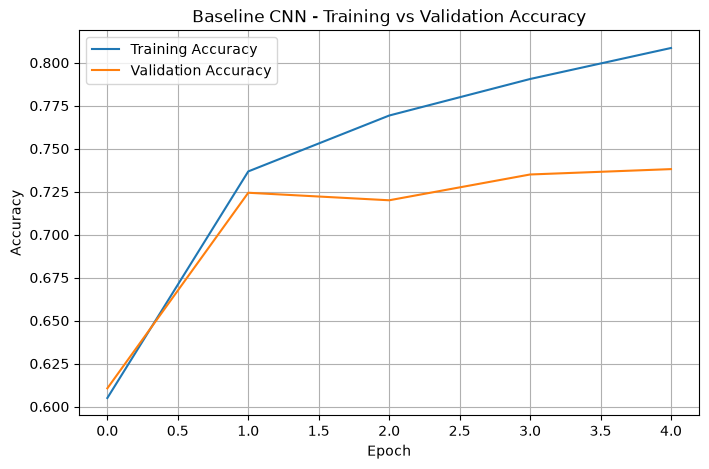

In [29]:
#Plot the training graph
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

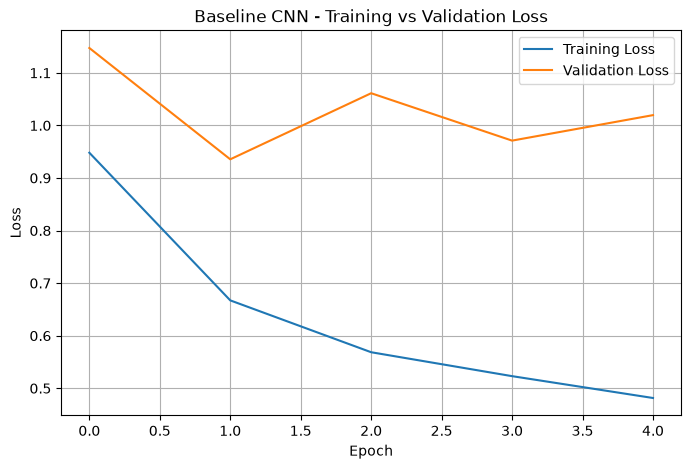

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
#Generate predection from baseline
import numpy as np

# Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in normalized_test_dataset:
    predictions = baseline_cnn.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test images:", len(y_true))
print("Predictions generated successfully.")

Total test images: 1600
Predictions generated successfully.


In [32]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.71      0.60      0.65       400
  meningioma       0.64      0.39      0.48       400
     notumor       0.74      0.96      0.84       400
   pituitary       0.76      0.94      0.84       400

    accuracy                           0.72      1600
   macro avg       0.71      0.72      0.70      1600
weighted avg       0.71      0.72      0.70      1600



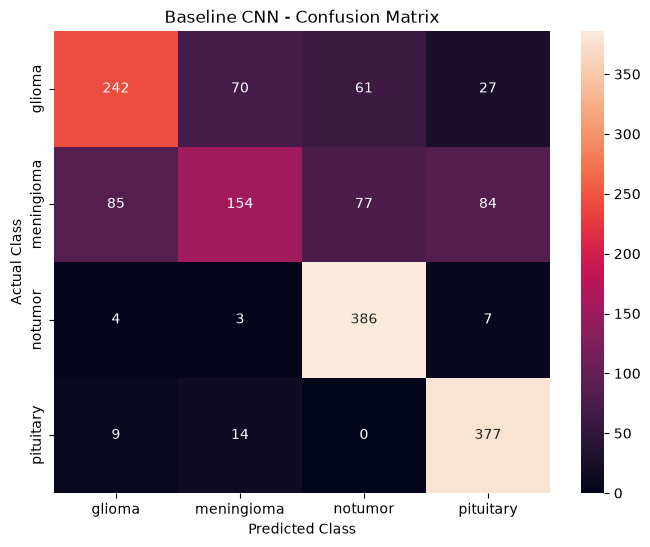

In [33]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Baseline CNN - Confusion Matrix")

plt.show()

In [34]:
#Create RestNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

# Pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Build classification model
inputs = layers.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# ResNet50 preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x)

# ResNet50 feature extractor
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)

resnet_model = Model(
    inputs,
    outputs
)

resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)       │               0 │ input_layer_3[0][0]        │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 224, 224)          │               0 │ data_augmentation[1][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 224, 224)          │               0 │ data_augmentation[1][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 224, 224)          │               0 │ data_augmentation[1][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 224, 224, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 224, 224, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 128)               │         262,272 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 4)                 │             516 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [35]:
#Compile forzen RestNet50
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("ResNet50 model compiled successfully.")

ResNet50 model compiled successfully.


In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_resnet = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_resnet = resnet_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[early_stopping_resnet]
)

Epoch 1/10


C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 840s 5s/step - accuracy: 0.6684 - loss: 0.8584 - precision: 0.7398 - recall: 0.5693 - val_accuracy: 0.7625 - val_loss: 0.6400 - val_precision: 0.8405 - val_recall: 0.6950
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 881s 5s/step - accuracy: 0.8154 - loss: 0.5152 - precision: 0.8497 - recall: 0.7611 - val_accuracy: 0.7850 - val_loss: 0.5644 - val_precision: 0.8499 - val_recall: 0.7431
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.8396 - loss: 0.4377 - precision: 0.8686 - recall: 0.7989 - val_accuracy: 0.8150 - val_loss: 0.5320 - val_precision: 0.8497 - val_recall: 0.7738
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8559 - loss: 0.3954 - precision: 0.8808 - recall: 0.8234 - val_accuracy: 0.8169 - val_loss: 0.5011 - val_precision: 0.8546 - val_recall: 0.7825
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8655 - loss: 0.3618 - precision: 0.8857 - recall: 0.8396 - val_accuracy: 0.8244 - val_loss: 0.4944 -

In [37]:
print("Epochs completed:", len(history_resnet.history["loss"]))

print("\nBest Training Accuracy:",
      max(history_resnet.history["accuracy"]))

print("Best Validation Accuracy:",
      max(history_resnet.history["val_accuracy"]))

print("Best Validation Loss:",
      min(history_resnet.history["val_loss"]))

Epochs completed: 10

Best Training Accuracy: 0.897678554058075
Best Validation Accuracy: 0.8506249785423279
Best Validation Loss: 0.4362765848636627


In [38]:
print("\nFinal recorded epoch:")
print("Training Loss:",
      history_resnet.history["loss"][-1])

print("Training Accuracy:",
      history_resnet.history["accuracy"][-1])

print("Validation Loss:",
      history_resnet.history["val_loss"][-1])

print("Validation Accuracy:",
      history_resnet.history["val_accuracy"][-1])


Final recorded epoch:
Training Loss: 0.27933189272880554
Training Accuracy: 0.897678554058075
Validation Loss: 0.44478535652160645
Validation Accuracy: 0.8487499952316284


In [39]:
#Evaluating RestNet50

In [40]:
import numpy as np
from sklearn.metrics import classification_report

y_true_resnet = []
y_pred_resnet = []

for images, labels in test_dataset:
    predictions = resnet_model.predict(images, verbose=0)

    y_true_resnet.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_resnet.extend(np.argmax(predictions, axis=1))

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)

print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=class_names,
    digits=2
))

              precision    recall  f1-score   support

      glioma       0.90      0.68      0.78       400
  meningioma       0.77      0.76      0.76       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.89      0.97      0.93       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.85      1600
weighted avg       0.85      0.85      0.85      1600



In [41]:
#Confusion Matrix

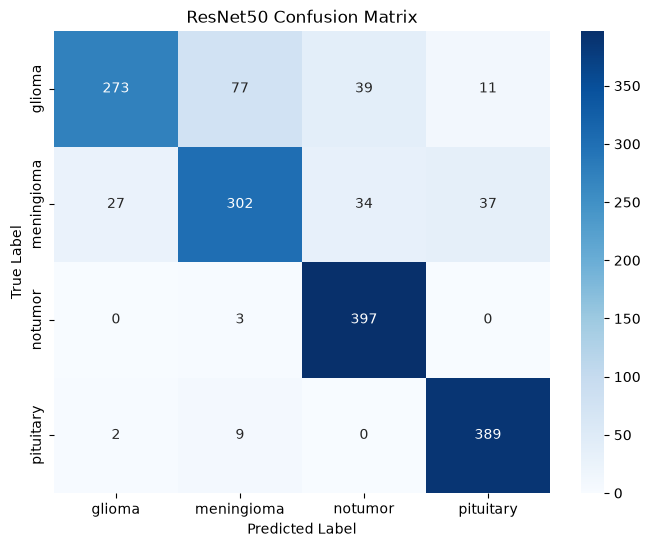

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [43]:
# ROC-AUC to evaluate how well model distingues between four classes

In [44]:
from sklearn.metrics import roc_auc_score

y_true_onehot = tf.keras.utils.to_categorical(
    y_true_resnet,
    num_classes=4
)

y_pred_prob_resnet = []

for images, labels in test_dataset:
    predictions = resnet_model.predict(images, verbose=0)
    y_pred_prob_resnet.extend(predictions)

y_pred_prob_resnet = np.array(y_pred_prob_resnet)

roc_auc = roc_auc_score(
    y_true_onehot,
    y_pred_prob_resnet,
    multi_class="ovr",
    average="macro"
)

print("Macro ROC-AUC:", roc_auc)

Macro ROC-AUC: 0.9676140624999999


In [45]:
resnet_model.save("medical_resnet50.keras")

print("Model saved successfully!")

Model saved successfully!


In [46]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_mri(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = resnet_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("Predicted Class:", predicted_class)
    print("Confidence: {:.2f}%".format(confidence))

In [47]:
#Prediction
image_path = "C:\Data Science\Testing\pituitary\Te-pi_1.jpg"

predict_mri(image_path)

Predicted Class: pituitary
Confidence: 93.06%


In [48]:
import os

print(os.getcwd())
print(os.path.exists("medical_resnet50.keras"))

C:\Users\Avishkar anand pawar\Data Science Project
True


In [49]:
import shutil
import os

source = r"C:\Users\Avishkar anand pawar\Data Science Project\medical_resnet50.keras"
destination = r"C:\Users\Avishkar anand pawar\Data Science Project\Medical_Image_App\medical_resnet50.keras"

shutil.copy2(source, destination)

print("Model copied successfully!")
print("File exists:", os.path.exists(destination))

Model copied successfully!
File exists: True
